# Laplaciano em Grafos

## Luis Gustavo Nonato  <br>
ICMC-USP

----

## Conteúdo
- Grafo e Matriz Laplaciana
- Propriedades da Matriz Laplaciana
    - Simetria e Semi Positividade
    - Propriedades do Espectro da Matriz Laplaciana

## <font color='blue'>Grafo e Matriz Laplaciana

Um grafo é definido por um conjunto da forma $G = (V,E,W)$
onde $V$ é o conjunto de vértices, $E$ é o conjunto de arestas que conectam os vértices e $W$ é um conjunto de pesos, não negativos, associados às arestas do grafo.

**Importante:** A definição de um grafo não envolve geometria, o que importa são as conexões entre os vértices e os pesos de tais conexões. Porém, informações geométricas são necessárias para visualizar o grafo (coordenadas dos vértices).


In [1]:
import numpy as np
import scipy as scp
import networkx as ntx
import matplotlib.pyplot as plt
%matplotlib inline

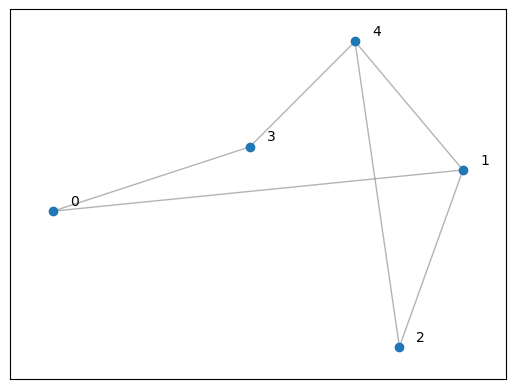

In [2]:
A = np.zeros((5,5))
A[0,:] = [0, 1, 0, 1, 0]
A[1,:] = [1, 0, 1, 0, 1]
A[2,:] = [0, 1, 0, 0, 1]
A[3,:] = [1, 0, 0, 0, 1]
A[4,:] = [0, 1, 1, 1, 0]

X = np.random.uniform(0,1,size=(5,2)) 

G = ntx.from_numpy_matrix(A)
ntx.draw_networkx_edges(G, pos=X, edge_color='dimgray',alpha=0.5)
plt.scatter(X[:,0],X[:,1])

eps=1e-2
for i, txt in enumerate(range(5)):
    plt.annotate(txt, (X[i,0]+eps, X[i,1]+eps))

### Matriz de Adjacência

Um grafo pode ser representado por uma matriz, chamada de _matriz de adjacência_. Denotando por $e_{ij}\in E$ uma aresta conectando o vértice $i$ ao vértice $j$ e por $w_{ij}$ o peso de tal aresta, a matriz de adjacência de uma grafo $G$ é definida como:

$$
W = \left\{\begin{array}{cl}
w_{ij} & \mbox{ se } e_{ij}\in E\\
0 & \mbox{caso contrario}
\end{array}\right.
$$

A matriz associada ao grafo da ilustração acima é:

$$
W = \begin{bmatrix}
0 & w_{01} & 0 & w_{03} & 0\\
w_{10} & 0 & w_{12} & 0 & w_{14}\\
0 & w_{21} & 0 & 0 & w_{24}\\
w_{30} & 0 & 0 & 0 & w_{34}\\
0 & w_{41} & w_{42} & w_{43} & 0
\end{bmatrix}
$$

Cada linha corresponde a um vértice e as colunas com entradas diferentes de zero correspondem aos vértices que são conectados por arestas.

### Matriz Laplaciana
Seja $D$ a matriz diagonal cujos elementos da diagonal são a soma de cada linha da matriz de adjacência $W$, ou seja,
$d_{ii}=\sum_j w_{ij}$. A matriz Laplaciana $L$ do grafo $G$ representado pela matriz de adjacência $W$ é definida como:

$$
L = D-W
$$

## <font color='blue'>Propriedades da Matriz Laplaciana

**Propriedade 1:** $L$ é simétrica e semi-definida positiva.

Demonstração:

A simetria é dada pela definição da matriz $W$ e pelo fato do grafo não ser dirigido. Vamos provar que $L$ é semi-definida positiva.
$$
x^\top L x \\
= x^\top D x - x^\top W x \\
= \sum_i d_{ii}x_i^2 - \sum_{ij}w_{ij}x_ix_j \\
= \frac{1}{2}\left(\sum_i d_{ii}x_i^2 - 2\sum_{ij}w_{ij}x_ix_j + \sum_j d_{jj}x_j^2\right)\\
= \frac{1}{2}\sum_{ij}w_{ij}(x_i-x_j)^2 \geq 0
$$

---

**Propriedade 2:** O menor autovalor de $L$ é zero e o autovetor correspondente é constante.

Demonstração:

Sabemos que os elementos da diagonal de $L$ são $l_{ii} = \sum_j w_{ij}$, e vamos assumir que $G$ tem $n$ vértices. Assim:

$$
Lx = \begin{bmatrix} l_{11}x_1\\ \vdots \\ l_{nn}x_n\end{bmatrix}-
\begin{bmatrix}
\sum_j w_{1j}x_j \\
\vdots\\
\sum_j w_{nj}x_j 
\end{bmatrix}
$$

Se fizer $x=[1,1,\ldots,1]$ (vetor constante), temos:

$$
Lx = \begin{bmatrix} l_{11}\\ \vdots \\ l_{nn}\end{bmatrix}-
\begin{bmatrix}
\sum_j w_{1j} \\
\vdots\\
\sum_j w_{nj} 
\end{bmatrix} = 0\\
\Downarrow\\
Lx = 0x
$$

Logo, $x$ vetor constante é autovetor de $L$ associado ao autovalor $0$ (o vetor constante pertence ao núcleo de $L$).

---

**Propriedade 3:** A multiplicidade do autovalor zero da matriz $L$ é igual ao número de componentes conexas do grafo G.

Demonstração: 

Vamos mostrar primeiro que se o grafo é conexo a multiplicidade do autovalor zero é $1$. Suponha que a multiplicidade seja maior que $1$, então existem pelo menos dois autovetores $u$ e $v$ associados ao autovalor zero. Logo:

$$
0 = u^\top (Lv) = u^\top Lv = \sum w_{ij}(u_i - v_j)^2
$$

Como $w_{ij}\geq 0$ não são todos núlos (grafo é conexo), temos que 
$$
(u_i - v_j)^2=0 \Longrightarrow u_i = v_j \quad \forall i,j
$$

Logo os vetores $u$ e $v$ são iguais, então a multiplicidade do autovalor zero é $1$.

Suponha agora que o grafo $G$ possui $k$ componentes conexas. Podemos enumerar os vértices de $G$ tal que L se torne uma matriz de blocos, cada bloco correspondendo a uma componente conexa.

$$
L = \begin{bmatrix}
L_1 &  & &\\
    & L_2 & &\\
    &     & \ddots & \\
    & & & L_k
\end{bmatrix}
$$

Cada $L_i$ é uma matriz Laplaciana de um grafo conexo, logo,
possui um autovalor zero com múltiplicidade $1$. Assim, o autovalor zero da matriz $L$ terá multipliciade $k$, o mesmo que o número de componentes conexas.

Os autovetores serão:

$$
u = \begin{bmatrix}
0 \\ 0 \\ \vdots \\ 0 \\ 1 \\ 1 \\  \vdots \\ 1 \\ 0 \\ 0\\  \vdots \\ 0
\end{bmatrix}
$$
---

Assumindo que o grafo possui $n$ vértices, qualquer vetor em $\mathbb{R}^n$ pode ser interpretado como uma função que associa um número real a cada vértice do grafo, ou seja, dado $x\in\mathbb{R}^n$,

$$
x:V\rightarrow\mathbb{R}
$$

Em particular, os autovetores da Laplaciana podem ser interpretados com funções reais definidas nos vértices do grafo.

In [3]:
# gerando uma matriz de adjacência aleatória com pesos 1 nas aresta
n = 20
row = np.random.randint(0,n,40)
col = np.random.randint(0,n,40)
A = np.zeros((n,n))
A[row,col] = 1
A[col,row] = 1
A[np.arange(n),np.arange(n)]=0
#print(A)

# calculando a Laplaciana
L = np.diag(np.sum(A,axis=1)) - A
#print(L)

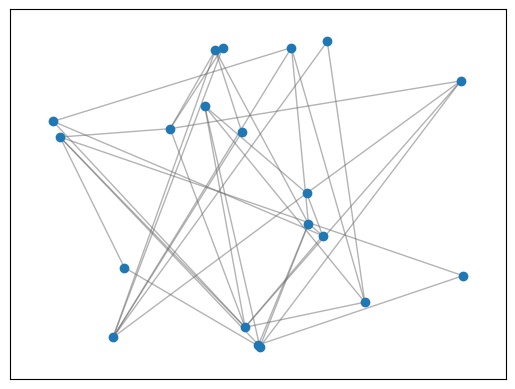

In [4]:
# gerando a posicao dos vértices aleatório
X = np.random.uniform(0,1,size=(n,2))
G = ntx.from_numpy_matrix(A)
ntx.draw_networkx_edges(G, pos=X, edge_color='dimgray',alpha=0.5)
plt.scatter(X[:,0],X[:,1])

[3.63592620e-15 7.57827431e-01 1.16659305e+00 1.43518220e+00
 1.61388476e+00 1.68462045e+00 2.28035031e+00 2.92586244e+00
 3.11679879e+00 3.33148231e+00 3.68889870e+00 3.92449797e+00
 4.07358383e+00 4.64402157e+00 5.43988856e+00 6.28697029e+00
 6.70507949e+00 6.77425594e+00 7.60800639e+00 8.54219553e+00]
[-0.04166008  0.00749326 -0.29515597  0.0762168   0.0975763   0.04815618
 -0.55939173 -0.09175678  0.00582963  0.2919391   0.12250904 -0.31148067
  0.04255253  0.1444815   0.18580552  0.29611689  0.21815724  0.01264529
 -0.39970509  0.14967104]


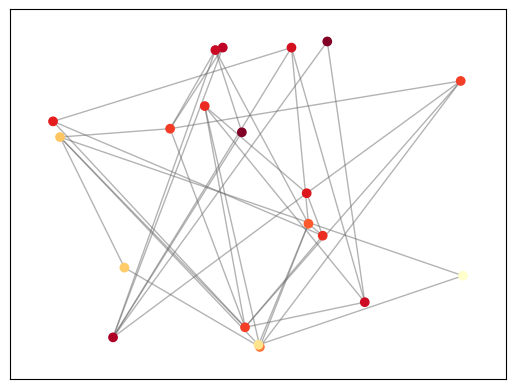

In [5]:
S,U = np.linalg.eigh(L)

ntx.draw_networkx_edges(G, pos=X, edge_color='dimgray',alpha=0.5)
# as cores correspondem aos valores da função dada pelo autovetor 
plt.scatter(X[:,0],X[:,1],c=U[:,1],cmap='YlOrRd')
print(S)
print(U[:,1])

**Propriedade 4:** Considere o vetor $u_2$, o qual corresponde ao autovetor associado ao menor autovalor não nulo. O vetor $u_2$ satisfaz a seguinte propriedade:

$$
u_2=\arg\min_{\|x\|=1}\{x\in \mathbb{R}^n | \sum_{e_{ij}\in E}w_{ij}(x_i - x_j)^2\}
$$
onde $n$ é o número de vértices do grafo.

**OBS:** O vetor $u_2$ de qualquer grafo é chamada de vetor de _Fiedler_.

Demostração:

Sabemos da demonstração da Propriedade 1) que:

$$
x^\top L x = \sum_{ij} w_{ij}(x_i-x_j)^2
$$

assim, minimizar $\sum_{ij} w_{ij}(x_i-x_j)^2$ é equivalente a minizar $x^\top L x$ (os $w_{ij}$ não fazem diferença pois são constantes no problema). Pelo Teorema de Rayleigh, sabemos que o mínimo da forma quadrádica 

$$
x^\top L x
$$

é obitido quando $x$ é o autovetor associado ao menor autovalor não nulo, portanto, o vetor de Fiedler.

---

A propriedade acima nos diz que a função não constante mais suave que pode ser definida em um grafo é dada por vetor de Fiedler.

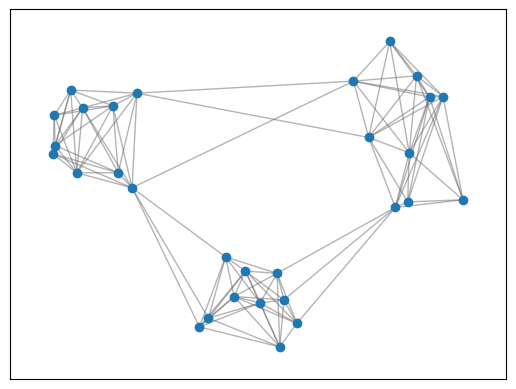

In [2]:
import connected_knn as cknn

n = 10
G1 = np.random.multivariate_normal((0,0),0.05*np.diag([1,1]),size=n)
G2 = np.random.multivariate_normal((1,1),0.05*np.diag([1,1]),size=n)
G = np.vstack((G1,G2))
G3 = np.random.multivariate_normal((-1,1),0.05*np.diag([1,1]),size=n)
G = np.vstack((G,G3))

# print(G.shape)
# plt.scatter(G[:,0],G[:,1])

A = cknn.connected_knn(G,extra_neighbors=3)
A = np.asarray(scp.sparse.csr_matrix.todense(A))
Ids = np.where(A != 0.0)
A[Ids] = 1.0
#print(A[0:2,:])

C = ntx.from_numpy_matrix(A)
ntx.draw_networkx_edges(C, pos=G, edge_color='dimgray',alpha=0.5)
plt.scatter(G[:,0],G[:,1])

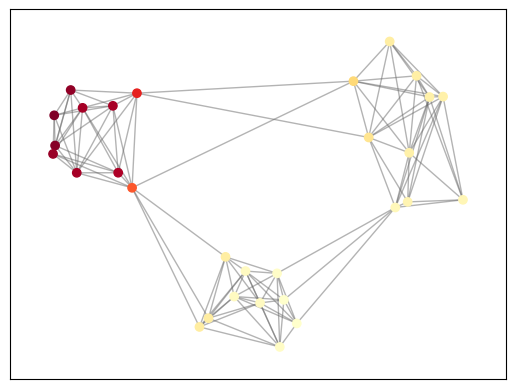

In [3]:
L = np.diag(np.sum(A,axis=1).ravel()) - A
S, U = np.linalg.eigh(L)

ntx.draw_networkx_edges(C, pos=G, edge_color='dimgray',alpha=0.5)
plt.scatter(G[:,0],G[:,1],c=U[:,1],cmap='YlOrRd')

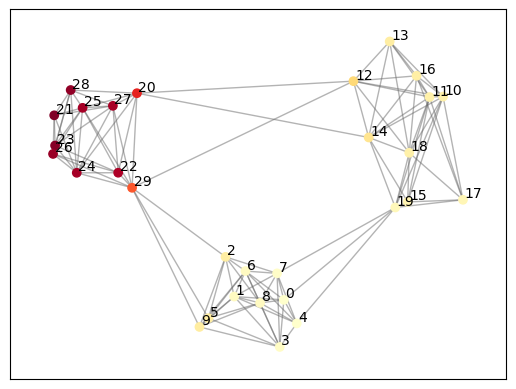

In [4]:
ids_ordenados = np.argsort(U[:,1])

ntx.draw_networkx_edges(C, pos=G, edge_color='dimgray',alpha=0.5)
plt.scatter(G[:,0],G[:,1],c=U[:,1],cmap='YlOrRd')

eps=1e-2
for i in ids_ordenados:
    plt.annotate(i, (G[i,0]+eps, G[i,1]+eps))

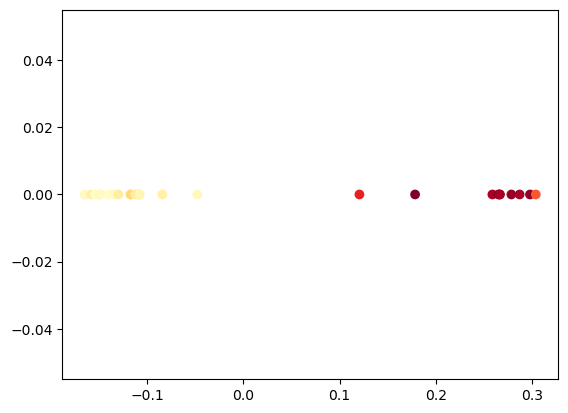

In [5]:
plt.scatter(U[ids_ordenados,1],np.zeros(len(ids_ordenados)),c=U[:,1],cmap='YlOrRd')

In [6]:
def plot_graph(A,p):
    n,n=A.shape
    fig, ax = plt.subplots()
    ax.scatter(p[:,0],p[:,1],color="gray",edgecolor='black')
    for i in range(0,n-1):
        for j in range(i+1,n):
            if (A[i,j] != 0):
                ax.plot([p[i,0],p[j,0]],[p[i,1],p[j,1]],color="gray",linewidth=0.5)
    #ax.show()
    return(fig, ax)


def adj_matrix(Tri_l,n):
    W = np.zeros((n,n))
    for t in Tri_l:
        W[t[0],t[1]]=1
        W[t[1],t[0]]=1
        W[t[0],t[2]]=1
        W[t[2],t[0]]=1
        W[t[1],t[2]]=1
        W[t[2],t[1]]=1

    return(W)

In [7]:
A = np.loadtxt('del500.adj')
X = np.loadtxt('del500.xy')

(<Figure size 640x480 with 1 Axes>, <Axes: >)

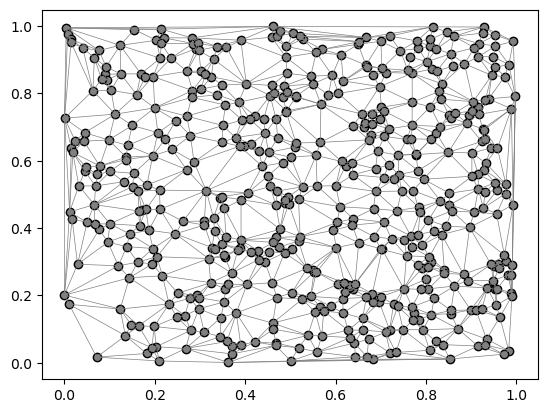

In [8]:
plot_graph(A,X)

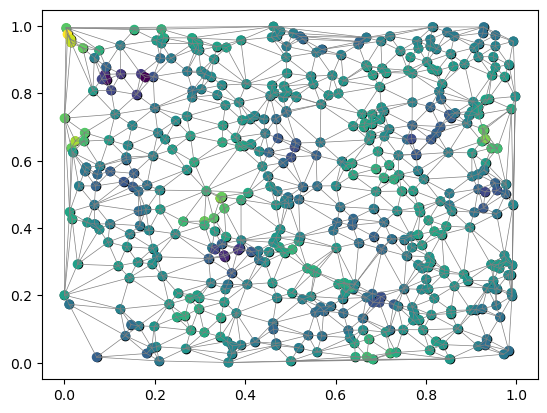

In [20]:
L = np.diag(np.sum(A,axis=1).ravel()) - A

S, U = np.linalg.eigh(L)

k=35
fig,ax = plot_graph(A,X)
ax = plt.scatter(X[:,0],X[:,1],c=U[:,k])

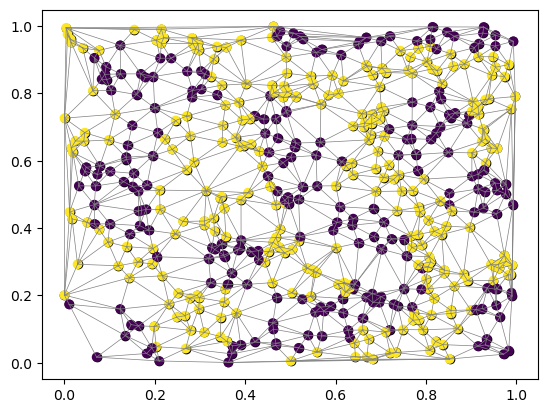

In [21]:
C = U[:,k]>=0
#print(C[0])
fig,ax = plot_graph(A,X)
ax = plt.scatter(X[:,0],X[:,1],c=C)

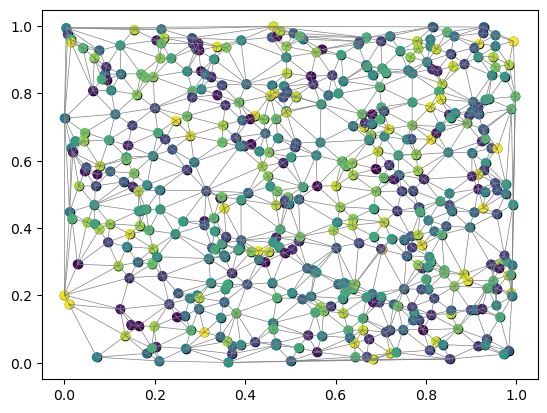

In [25]:
D = np.diag([1,1])

N = np.exp((np.linalg.norm(X-0.5,axis=1))**2/1000.0)
Np = N.copy()
Np = Np + np.random.uniform(-0.005,0.005,size=N.shape)
#Np = np.random.uniform(-0.1,0.1,size=N.shape)


fig,ax = plot_graph(A,X)
ax = plt.scatter(X[:,0],X[:,1],c=Np)

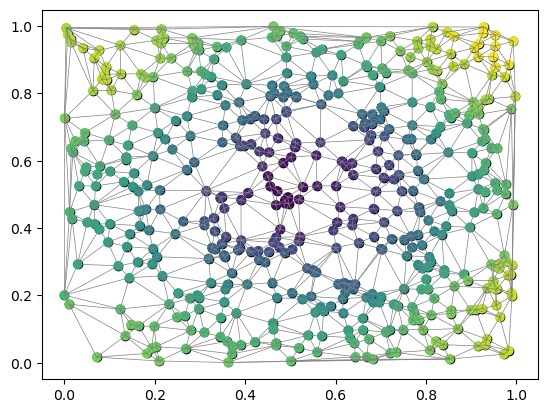

In [27]:
Xh = np.zeros(N.shape)
for i in range(1,0):
    Xh += np.dot(U[:,i].T,N)*U[:,i]
    
fig,ax = plot_graph(A,X)
ax = plt.scatter(X[:,0],X[:,1],c=Xh)

(499,)


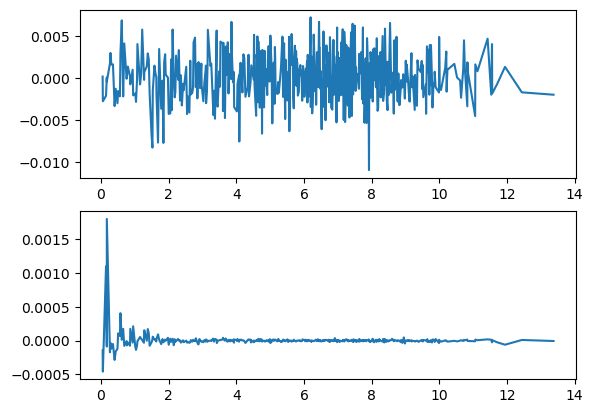

In [31]:
spec = np.dot(U[:,1:].T,N)
specp = np.dot(U[:,1:].T,Np)

print(spec.shape)

fig, ax = plt.subplots(2)

ax[0].plot(S[1:],specp)
ax[1].plot(S[1:],spec)